In [1]:
using ITensors
using ITensorMPS
using PolyChaos
using LinearAlgebra
using Plots
#using Observers #for TDVP
using JLD2
using ProgressMeter
using Kronecker
using SparseArrays

include(dirname(dirname(@__DIR__))*"\\src\\chain_mapping.jl")
include(dirname(dirname(@__DIR__))*"\\src\\map_calculations.jl")

Main.map_calculations

Correlation matrix propagator


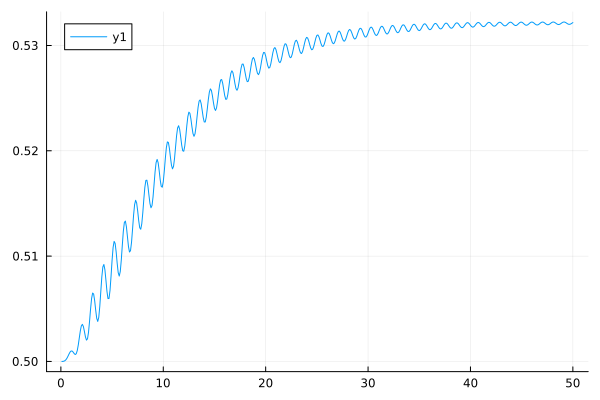

Calculating Λ(t) from the single particle correlation matrix.

Progress:   3%|██                                       |  ETA: 0:00:04

Progress: 100%|█████████████████████████████████████████| Time: 0:00:03


computing map spectra
computing propagator spectra
norm(Λ_vec[end] * map_calculations.vectorise_mat(ρi) - map_calculations.vectorise_mat(ρ_evolved)) = 1.831009650867239e-14


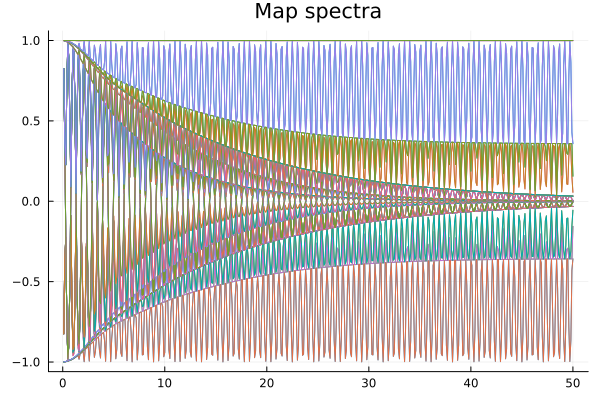

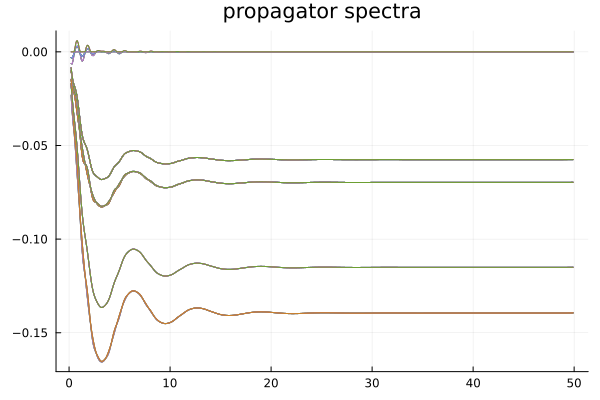

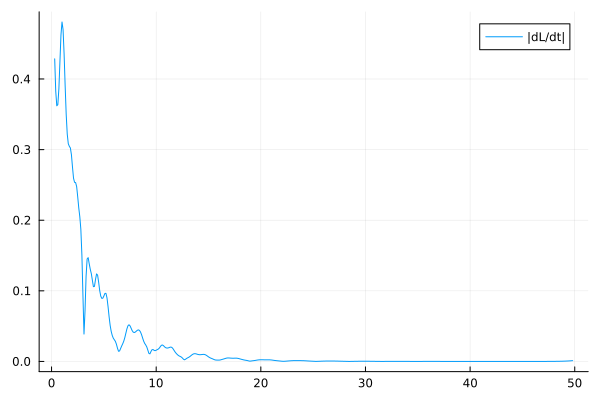

In [5]:

bath = chain_mapping.BathParameters(Γ = 0.2,β = 10.0,μ = 0.1,D = 1.0,N = 50,spectral_function="smoothed box")

system = chain_mapping.RingParameters(B = 1,J = 1,N_ring = 3,occupations=[0.2,0.8,0.1], compute_maps_bool = true)

symmetry_subspace = "Full"#"Number conserving"

Hsingle,initial_correlation_matrix,sys_anc_inds,system_inds,ancilla_inds = chain_mapping.build_thermofield_ring_model(bath,system);

#evolution parameters
δt = 0.1
T = 50
times = range(δt,stop=T,step=δt)

println("Correlation matrix propagator")
corrs = map_calculations.propagate_correlations(initial_correlation_matrix,Hsingle,times)
den = [corr[1,1] for corr in corrs]
display(Plots.plot(times,real.(den)))


if system.compute_maps_bool
    Λ_vec,L_vec = map_calculations.compute_maps(corrs,δt,sys_anc_inds,ancilla_inds;symmetry_subspace=symmetry_subspace)
    spectra_Λ,spectra_L = map_calculations.compute_spectra(Λ_vec,L_vec)
    propagator_steadystates  = [map_calculations.NESS_extraction(L,"L",system.N_ring;symmetry_subspace=symmetry_subspace) for L in L_vec]
    map_steadystates = [map_calculations.NESS_extraction(Λ,"Λ",system.N_ring;symmetry_subspace=symmetry_subspace) for Λ in Λ_vec]

    dLdt = map_calculations.differentiate(L_vec,δt)

    #map check
    ρi = map_calculations.calculate_ρ_from_correlation_matrix(initial_correlation_matrix,system_inds; eps=1e-14)
    ρ_evolved = map_calculations.calculate_ρ_from_correlation_matrix(corrs[end],system_inds; eps=1e-14)
    if symmetry_subspace =="Number conserving"
        @show(norm(map_calculations.expand_Λ(Λ_vec[end],system.N_ring)*map_calculations.vectorise_mat(ρi)-map_calculations.vectorise_mat(ρ_evolved)))
    else
        @show(norm(Λ_vec[end]*map_calculations.vectorise_mat(ρi)-map_calculations.vectorise_mat(ρ_evolved)))

    end
    display(Plots.plot(times,real.(spectra_Λ),label=false,title="Map spectra"))
    display(Plots.plot(times[2:end-1],real.(spectra_L),ms=0.1,label=false,title="propagator spectra"))

    display(plot(times[3:end-2],norm.(dLdt),label="|dL/dt|"))
end

In [7]:
L = L_vec[end]
eigen(L).values

64-element Vector{ComplexF64}:
     -0.1394004724511604 - 2.8947677588320175e-13im
    -0.13940047245114084 - 1.8231335074451321e-13im
     -0.1394004724508854 + 3.20338833397941e-14im
      -0.139400472450794 - 1.2158676843121441e-14im
    -0.13939989693378377 + 2.015054789694659e-13im
     -0.1393998969336127 + 5.5249043463470215e-14im
    -0.13939989693352994 + 1.0677794096014022e-13im
    -0.13939989693347782 - 1.4500945828163585e-14im
    -0.11502384268962107 + 5.649928609622121im
    -0.11502384268957867 - 5.649928609622462im
    -0.11502384268949273 + 5.6499286096217585im
    -0.11502384268937718 + 5.649928609622088im
    -0.11502384268936497 - 5.649928609622183im
                         ⋮
   -2.958051565915554e-7 - 5.649375746950003im
  -2.9580513771776396e-7 - 5.64937574694989im
   -2.958050207890804e-7 - 5.649375746950007im
  -2.9580500138237653e-7 + 5.649375746949879im
  -2.9580493792185497e-7 - 5.649375746950081im
   -2.958049151596809e-7 + 5.649375746949931im
   -2.958048

In [8]:
eigen(L).vectors[:,end]

64-element Vector{ComplexF64}:
  -0.0014733801186818675 - 0.0008946044638276153im
   5.411149862351907e-16 - 1.5108055813539626e-15im
  -3.2756969514493755e-5 + 0.0001699719406290066im
 -4.1551570647280536e-16 + 1.6497591650319877e-15im
   3.2756969513166875e-5 - 0.0001699719406256584im
   7.205588616788759e-16 - 1.7848907536672644e-15im
  -9.257000784760545e-16 + 1.5092054894219365e-15im
 -1.7492362440366006e-16 - 3.3020694668003047e-17im
 -1.5565428601400352e-15 - 1.901606536972523e-15im
   -0.013811609057092734 - 0.008386103975791419im
   -0.011101170086281576 - 0.00674038399723793im
  0.00030706534680453477 - 0.0015933343477246592im
   -0.011101170086260138 - 0.006740383997268671im
                         ⋮
   0.0021592877407854106 - 0.002057287515888232im
     0.12850935576720662 + 2.0278079701507856e-9im
     0.30236194930108634 - 1.8789794511975266e-9im
  1.2608942085997341e-15 + 6.603474631433337e-16im
  4.3876069769930174e-17 - 5.58338408811059e-17im
  4.4412637837225357e-17 

In [10]:
eigen(L).vectors[:,62]

64-element Vector{ComplexF64}:
    1.093252861380782e-5 - 4.361832700472503e-5im
 -1.4951434249815835e-15 + 2.610584072072503e-15im
  -0.0001033012072887493 - 2.4796380502838443e-5im
  -1.106401245283449e-15 + 5.408294326791472e-16im
  0.00010330120729066373 + 2.4796380501650185e-5im
   9.728349296471942e-16 - 6.051640077918596e-16im
  3.1623081356990647e-16 + 1.4208747645737533e-15im
   7.620290351240526e-19 - 8.973822833052603e-17im
   1.902004052030542e-14 + 1.3848050850961489e-14im
  0.00010248252825150565 - 0.00040888240454788657im
    8.237098002126424e-5 - 0.00032864186479564326im
   0.0009683554312860769 + 0.00023244183775895027im
    8.237098002153394e-5 - 0.0003286418647969202im
                         ⋮
    -0.21491554087369602 + 1.3352789707266055e-10im
    0.000526484381938276 + 0.0010798007662495546im
   0.0012387334724822602 + 0.002540598416205681im
  -1.784944919723954e-15 + 2.6123270858718673e-15im
   3.999953549105371e-17 - 2.1132603862639733e-17im
  -4.3071889221102

In [37]:
eigen(L).vectors[:,19]

20-element Vector{ComplexF64}:
    0.4010673368221457 + 0.0im
    0.3874685344386803 + 2.6121909912912855e-9im
 -0.008240491744202608 + 2.3923557397262374e-9im
 -0.008240491744124667 + 2.3924414710614628e-9im
 -0.008240491744139947 + 2.945082025040263e-9im
   0.09663838320740424 + 0.12091541480727352im
    0.3007497576770592 - 0.1209154093544005im
     0.093192393934898 + 0.11681559937344446im
    0.2903830683863856 - 0.1168155912978575im
  -0.00419374606689354 + 0.00496874253741693im
  -0.00824049174418641 + 2.9449838613755663e-9im
    0.3007497576770894 - 0.12091540935428452im
   0.09663838320738433 + 0.12091541480726117im
    0.2903830683861072 - 0.11681559129784555im
   0.09319239393454867 + 0.11681559937373953im
 0.0041937460667997835 - 0.00496874253710019im
 -0.004193745733935741 + 0.004968742818656561im
  0.004193745733329288 - 0.004968742818347275im
  -0.20223897469555813 + 0.23961240925956315im
  -0.19520942874854202 + 0.23128381529222428im

In [5]:

# anim = @animate for i=1:length(times)
#     Plots.scatter(real.(spectra_Λ[i,:]),imag.(spectra_Λ[i,:]),
#     xlim=(-1,1),ylim=(-1,1),
#     xlabel = "Re",
#     ylabel = "Im",label = "",ms=2)
# end
# gif(anim,"map spectrum1.gif")


# anim = @animate for i=1:length(times)-2
#     Plots.scatter(real.(spectra_L[i,:]),imag.(spectra_L[i,:]),
#     xlim=(-0.25,0.02),
#     xlabel = "Re",
#     ylabel = "Im",label = "",ms=2)
# end
# gif(anim,"propagator spectrum2.gif")